In [ ]:
import os
import glob
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import esmpy
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as ticker
from datetime import datetime
import subprocess

In [ ]:
def to_scrip(xc, yc, xo, yo, mc, dims, output_file='scrip.nc'):
    """
    Writes grid in SCRIP format
    """

    # Create new dataset in SCRIP format
    out = xr.Dataset()

    # Fill with data
    out['grid_dims'] = xr.DataArray(np.array(dims, dtype=np.int32), dims=('grid_rank',))
    out['grid_center_lon'] = xr.DataArray(xc, dims=('grid_size'), attrs={'units': 'degrees'})
    out['grid_center_lat'] = xr.DataArray(yc, dims=('grid_size'), attrs={'units': 'degrees'})
    out['grid_corner_lon'] = xr.DataArray(xo, dims=('grid_size','grid_corners'), attrs={'units': 'degrees'}).astype(dtype=np.float64, order='F')
    out['grid_corner_lat'] = xr.DataArray(yo, dims=('grid_size','grid_corners'), attrs={'units': 'degrees'}).astype(dtype=np.float64, order='F')
    out['grid_imask'] = xr.DataArray(mc, dims=('grid_size'), attrs={'units': 'unitless'})

    # Force no '_FillValue' if not specified
    for v in out.variables:
        if '_FillValue' not in out[v].encoding:
            out[v].encoding['_FillValue'] = None    

    # Add global attributes
    out.attrs = {'title': 'Grid with {} size'.format('x'.join(list(map(str,dims)))),
                 'date_created': '{}'.format(datetime.now()),
                 'conventions': 'SCRIP'}

    # Write dataset
    out.to_netcdf(output_file)
    return(output_file)

def scrip_to_mesh(input_file, output_file='mesh.nc'):
    """
    Convert scrip.nc to ESMF mesh format using ESMF_Scrip2Unstruct tool
    """
    # Check ESMFMKFILE environment variable to find out location of executable
    if os.environ['ESMFMKFILE']:
        # Open file and parse it
        with open(os.environ['ESMFMKFILE']) as f:
            bindir = [x.strip().split('=')[1] for x in f.readlines() if 'ESMF_APPSDIR' in x]
            # Run command
            if bindir:
                exe = os.path.join(bindir[0], 'ESMF_Scrip2Unstruct')
                log = os.path.join(os.path.dirname(output_file), 'mesh.log')
                cmd = f"{exe} {input_file} {output_file} 0 >{log} 2>&1"                
                print("Running: {}".format(cmd))
                result = subprocess.check_call(cmd, shell=True)
            else:
                print('Could not find ESMF_Scrip2Unstruct command. Please set ESMFMKFILE environment variable!')
                sys.exit()

def calc_corners(xc, yc, delta=0.25):
    """
    Calculate corner coordinates by averaging neighbor cells
    It follows the approach initially developed by NCL and made
    available through calc_SCRIP_corners_noboundaries()
    """
    # Get sizes of original array
    ny, nx = xc.shape

    # Extend array that stores center coordinates
    xc_ext = np.pad(xc, ((1,1), (1,1)), constant_values=(0, 0))
    yc_ext = np.pad(yc, ((1,1), (1,1)), constant_values=(0, 0))

    # Get sizes, extended array
    ny_ext, nx_ext = xc_ext.shape

    # Fill missing part of expanded array
    # Bottom row, minus corners (left side in data)
    xc_ext[1:ny_ext-1,0] = mirrorP2P(xc[:,1], xc[:,0])
    yc_ext[1:ny_ext-1,0] = mirrorP2P(yc[:,1], yc[:,0])

    # Top, minus corners (right side in data)
    xc_ext[1:ny_ext-1,nx_ext-1] = mirrorP2P(xc[:,nx-2], xc[:,nx-1])
    yc_ext[1:ny_ext-1,nx_ext-1] = mirrorP2P(yc[:,nx-2], yc[:,nx-1])

    # Left, minus corners (top side in data)
    xc_ext[0,1:nx_ext-1] = mirrorP2P(xc[1,:], xc[0,:])
    yc_ext[0,1:nx_ext-1] = mirrorP2P(yc[1,:], yc[0,:])

    # Right, minus corners (bottom side in data)
    xc_ext[ny_ext-1,1:nx_ext-1] = mirrorP2P(xc[ny-2,:], xc[ny-1,:])
    yc_ext[ny_ext-1,1:nx_ext-1] = mirrorP2P(yc[ny-2,:], yc[ny-1,:])

    # Lower left corner (upper left corner in data)
    xc_ext[0,0] = mirrorP2P(xc[1,1], xc[0,0])
    yc_ext[0,0] = mirrorP2P(yc[1,1], yc[0,0])

    # Upper right corner (lower right corner in data)
    xc_ext[ny_ext-1,nx_ext-1] = mirrorP2P(xc[ny-2,nx-2], xc[ny-1,nx-1])
    yc_ext[ny_ext-1,nx_ext-1] = mirrorP2P(yc[ny-2,nx-2], yc[ny-1,nx-1])

    # Lower right corner (upper right corner in data)
    xc_ext[0,nx_ext-1] = mirrorP2P(xc[1,nx-2], xc[0,nx-1])
    yc_ext[0,nx_ext-1] = mirrorP2P(yc[1,nx-2], yc[0,nx-1])

    # Upper left corner (lower left corner in data)
    xc_ext[ny_ext-1,0] = mirrorP2P(xc[ny-2,1], xc[ny-1,0])
    yc_ext[ny_ext-1,0] = mirrorP2P(yc[ny-2,1], yc[ny-1,0])

    # Fix boundary corners if they go over
    xc_ext = xc_ext % 360
    yc_ext = np.where(yc_ext > 90.0, 90.0, yc_ext)
    yc_ext = np.where(yc_ext < -90.0, -90.0, yc_ext)

    # The cell center of the extended grid, which
    # would be the corner coordinates for the original grid
    xo = xc_ext[:,1:nx_ext]+xc_ext[:,0:nx_ext-1]
    xo = delta*(xo[1:ny_ext,:]+xo[0:ny_ext-1,:])
    yo = yc_ext[:,1:nx_ext]+yc_ext[:,0:nx_ext-1]
    yo = delta*(yo[1:ny_ext,:]+yo[0:ny_ext-1,:])

    # Create flattened version of corner coordinates
    kernel = np.array([[1,1], [1,1]])
    xo = arrays_from_kernel(xo, kernel).reshape(ny,nx,-1).reshape(-1,kernel.size)
    xo = xo[:,[0, 1, 3, 2]]
    yo = arrays_from_kernel(yo, kernel).reshape(ny,nx,-1).reshape(-1,kernel.size)
    yo = yo[:,[0, 1, 3, 2]]

    # Return flatten arrays
    return(np.ndarray.flatten(xc),
           np.ndarray.flatten(yc),
           xo,
           yo)

def mirrorP2P(p1, p0):
    """
    This functions calculates the mirror of p1 with respect to po
    and ported from the NCL code
    """
    dVec = p1-p0
    return(p0-dVec)

def arrays_from_kernel(arr, kernel):
    windows = sliding_window(arr, kernel.shape)
    return np.where(kernel, windows, 0)

def sliding_window(data, win_shape, **kwargs):
    assert data.ndim == len(win_shape)
    shape = tuple(dn - wn + 1 for dn, wn in zip(data.shape, win_shape)) + win_shape
    strides = data.strides * 2
    return np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides, **kwargs)

In [ ]:
# Define bounding box limits - ERA5 data over ROMS grid
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

vars = {
    "10u"  : "u10",
    "10v"  : "v10",
    "msl"  : "msl",
    "2t"   : "t2m",
    "2rh"  : "rh2",
    "tp"   : "tp",
    "lwdn" : "strd",
    "swnet": "ssr",
}

data_path = '/glade/derecho/scratch/turuncu/data/Data_aurora'
files_pred = sorted(glob.glob(os.path.join(data_path, "predictions_irene_tp", "pred_*.nc")))
files_input = sorted(glob.glob(os.path.join(data_path, "split_files", "data_*.nc")))

In [ ]:
# Create ESMF mesh file for source data
ds_era5 = xr.open_dataset(files_input split_files)
    ds_era5 = ds_era5.sel(time=time_pred)
    ds_era5 = ds_era5.load().reindex(latitude=ds_era5.latitude[::-1])
    ds_era5_subset = ds_era5.sel(longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))[list(vars.values())]
    ds_era5_subset.to_netcdf(f"data_{date_str}_subset.nc")
xc = grid.lon_rho
xc = xc.rename({'xi_rho' : 'x'}).to_numpy()
yc = grid.lat_rho
yc = yc.rename({'eta_rho' : 'y'}).to_numpy()
mc = np.ndarray.flatten(grid.mask_rho.to_numpy())
xc_1, yc_1, xo_2, yo_2 = calc_corners(xc, yc)
scrip_file = to_scrip(xc_1, yc_1, xo_2, yo_2, mc, xc.shape[::-1])
scrip_to_mesh(scrip_file, output_file='ROMS_ESMFmesh.nc')

In [29]:
# Create ESMF mesh file for ROMS
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')
xc = grid.lon_rho
xc = xc.rename({'xi_rho' : 'x'}).to_numpy()
yc = grid.lat_rho
yc = yc.rename({'eta_rho' : 'y'}).to_numpy()
mc = np.ndarray.flatten(grid.mask_rho.to_numpy())
xc_1, yc_1, xo_2, yo_2 = calc_corners(xc, yc)
scrip_file = to_scrip(xc_1, yc_1, xo_2, yo_2, mc, xc.shape[::-1])
scrip_to_mesh(scrip_file, output_file='ROMS_ESMFmesh.nc')

Running: /glade/work/turuncu/ML/envs/aurora/bin/ESMF_Scrip2Unstruct scrip.nc ROMS_ESMFmesh.nc 0 >mesh.log 2>&1


In [4]:
# Define bounding box limits - ERA5 data over ROMS grid
min_lat, max_lat = 25, 55
min_lon, max_lon = 270, 310

# List of variables used for coupling
vars = {
    "10u"  : ["u10", "m/s"],
    "10v"  : ["v10", "m/s"],
    "msl"  : ["msl", "hPa"],
    "2t"   : ["t2m", "K"],
    "2rh"  : ["rh2", "1"],
    "tp"   : ["tp" , "m/s"],
    "lwdn" : ["strd", "W/m2"],
    "swnet": ["ssr", "W/m2"],
}

# Get land-sea mask information
ds_pred = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Data_aurora/predictions_irene_tp/pred_2011-08-21T12:00:00.nc')
ds_pred = ds_pred.reindex(latitude=ds_pred.latitude[::-1])
ds_pred_subset = ds_pred.sel(longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))
lsm = ds_pred_subset.slt.isel(time=0) == 0

# Load statistics
ds_stats = xr.open_dataset('/glade/derecho/scratch/turuncu/data/Data_aurora/prediction_stats_irene_tp/stat_surface_2d_tmean.nc')
ds_stats = ds_stats.reindex(latitude=ds_stats.latitude[::-1])
ds_stats_subset = ds_stats.sel(longitude=slice(min_lon, max_lon), latitude=slice(min_lat, max_lat))
ds_stats_subset

<xarray.Dataset> Size: 86MB
Dimensions:       (time: 1, longitude: 161, latitude: 121, rollout_step: 37,
                   bnds: 2)
Coordinates:
  * time          (time) datetime64[ns] 8B 2011-08-25T18:00:00
  * longitude     (longitude) float32 644B 270.0 270.2 270.5 ... 309.8 310.0
  * latitude      (latitude) float32 484B 25.0 25.25 25.5 ... 54.5 54.75 55.0
  * rollout_step  (rollout_step) float64 296B 0.0 6.0 12.0 ... 204.0 210.0 216.0
Dimensions without coordinates: bnds
Data variables: (12/31)
    time_bnds     (time, bnds) datetime64[ns] 16B ...
    ACC_2t        (time, rollout_step, latitude, longitude) float32 3MB ...
    RMSE_2t       (time, rollout_step, latitude, longitude) float32 3MB ...
    ACC_2dt       (time, rollout_step, latitude, longitude) float32 3MB ...
    RMSE_2dt      (time, rollout_step, latitude, longitude) float32 3MB ...
    ACC_2q        (time, rollout_step, latitude, longitude) float32 3MB ...
    ...            ...
    ACC_lwnet     (time, rollout_step, latitude, longitude) float32 3MB ...
    RMSE_lwnet    (time, rollout_step, latitude, longitude) float32 3MB ...
    ACC_lwdn      (time, rollout_step, latitude, longitude) float32 3MB ...
    RMSE_lwdn     (time, rollout_step, latitude, longitude) float32 3MB ...
    ACC_swdn      (time, rollout_step, latitude, longitude) float32 3MB ...
    RMSE_swdn     (time, rollout_step, latitude, longitude) float32 3MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.2 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Mon Mar 23 09:31:44 2026: cdo timmean stat_surface_2d.nc st...
    NCO:          netCDF Operators version 5.3.4 (Homepage = http://nco.sf.ne...
    CDO:          Climate Data Operators version 2.5.2 (https://mpimet.mpg.de...

In [33]:
# Load roms grid
grid = xr.open_dataset('../run/Data/ROMS/irene_roms_grid.nc')

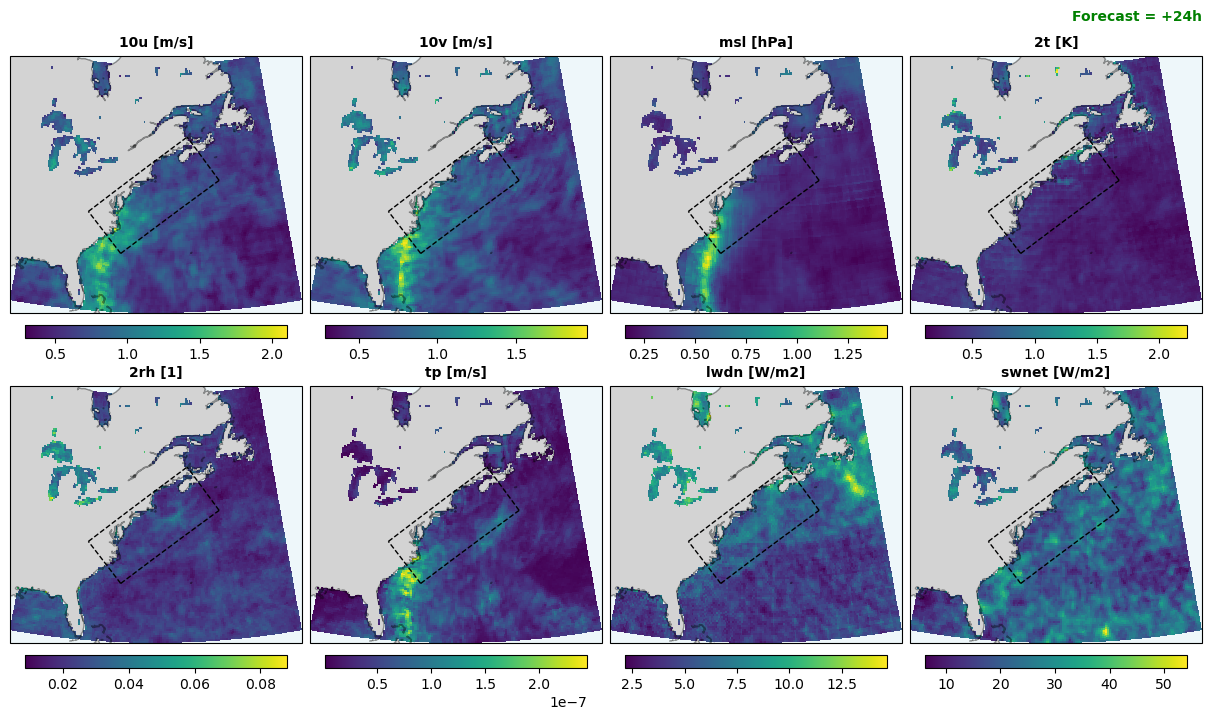

In [35]:
# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
fig, axs = plt.subplots(2, 4, figsize=(12,7), layout='constrained', subplot_kw={'projection': projection})
ax = axs.flat

# Loop over variables
icol = 0
for v, attr in vars.items():
    # Plot RMSE
    #data0 = ds_stats_subset[f'RMSE_{v}'].isel(time=0, rollout_step=range(0,4)).where(lsm).mean(['rollout_step'])
    data0 = ds_stats_subset[f'RMSE_{v}'].isel(time=0, rollout_step=3).where(lsm)
    im0 = data0.plot(ax=ax[icol], transform=ccrs.PlateCarree(), cmap='viridis', add_colorbar=False)
    fig.colorbar(im0, ax=ax[icol], pad=0.04, aspect=20, shrink=0.9, label='', orientation='horizontal')
            
    # Add coastline
    ax[icol].add_feature(cfeature.COASTLINE, alpha=0.4)
    ax[icol].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Set title
    ax[icol].set_title(f'{v} [{attr[1]}]', fontweight='bold', fontsize=10)

    # Add rollout step
    if icol == 3:
        ax[icol].text(1.0, 1.15, f"Forecast = +24h", transform=ax[icol].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    # Add ROMS grid
    ax[icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax[icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax[icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax[icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right
        
    icol=icol+1

filename = "plot_spatial_rmse.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

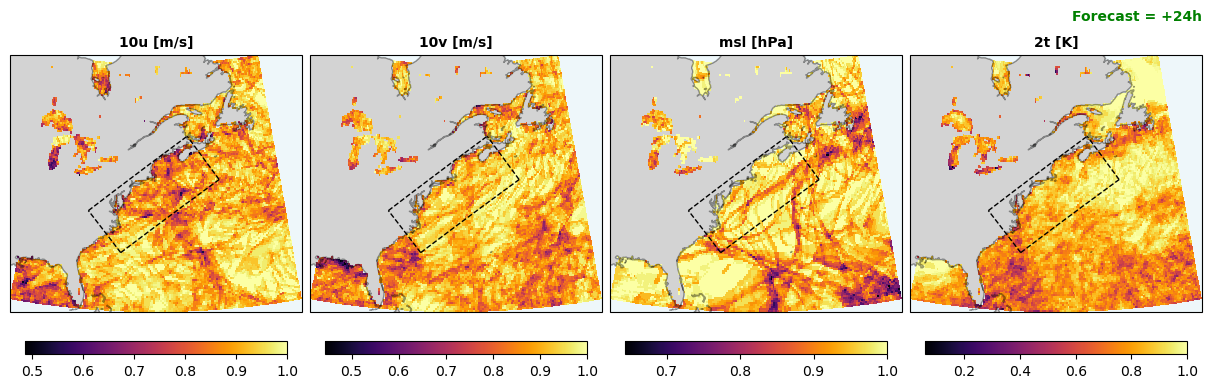

In [39]:
# Set projection
projection = ccrs.LambertConformal(
    central_longitude=(min_lon+max_lon)/2.0, 
    central_latitude=(min_lat+max_lat)/2.0, 
    standard_parallels=(20.0, 40.0)
)

# Create figure
fig, axs = plt.subplots(1, 4, figsize=(12,7), layout='constrained', subplot_kw={'projection': projection})
ax = axs.flat

# Remove keys without ACC
keys_to_remove = ["2rh", "lwdn", "swnet", "tp"]
vars_filtered = {k: v for k, v in vars.items() if k not in keys_to_remove}

# Loop over variables
icol = 0
for v, attr in vars_filtered.items():
    # Plot RMSE
    data0 = ds_stats_subset[f'ACC_{v}'].isel(time=0, rollout_step=range(0,4)).where(lsm).mean(['rollout_step'])
    #data0 = ds_stats_subset[f'ACC_{v}'].isel(time=0, rollout_step=3).where(lsm)
    im0 = data0.plot(ax=ax[icol], transform=ccrs.PlateCarree(), cmap='inferno', add_colorbar=False)
    fig.colorbar(im0, ax=ax[icol], pad=0.04, aspect=20, shrink=0.9, label='', orientation='horizontal')

    # Add coastline
    ax[icol].add_feature(cfeature.COASTLINE, alpha=0.4)
    ax[icol].add_feature(cfeature.LAND, facecolor='lightgray')
    ax[icol].add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2)

    # Set title
    ax[icol].set_title(f'{v} [{attr[1]}]', fontweight='bold', fontsize=10)

    # Add rollout step
    if icol == 3:
        ax[icol].text(1.0, 1.15, f"Forecast = +24h", transform=ax[icol].transAxes, ha='right', va='center', fontweight='bold', color='green', fontsize=10)

    # Add ROMS grid
    ax[icol].plot(grid.lon_rho[0, :], grid.lat_rho[0, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Bottom
    ax[icol].plot(grid.lon_rho[:, 0], grid.lat_rho[:, 0], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Left
    ax[icol].plot(grid.lon_rho[-1, :], grid.lat_rho[-1, :], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Top
    ax[icol].plot(grid.lon_rho[:, -1], grid.lat_rho[:, -1], color='black', linewidth=1, linestyle='--', transform=ccrs.PlateCarree()) # Right
    
    icol=icol+1

filename = "plot_spatial_acc.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)

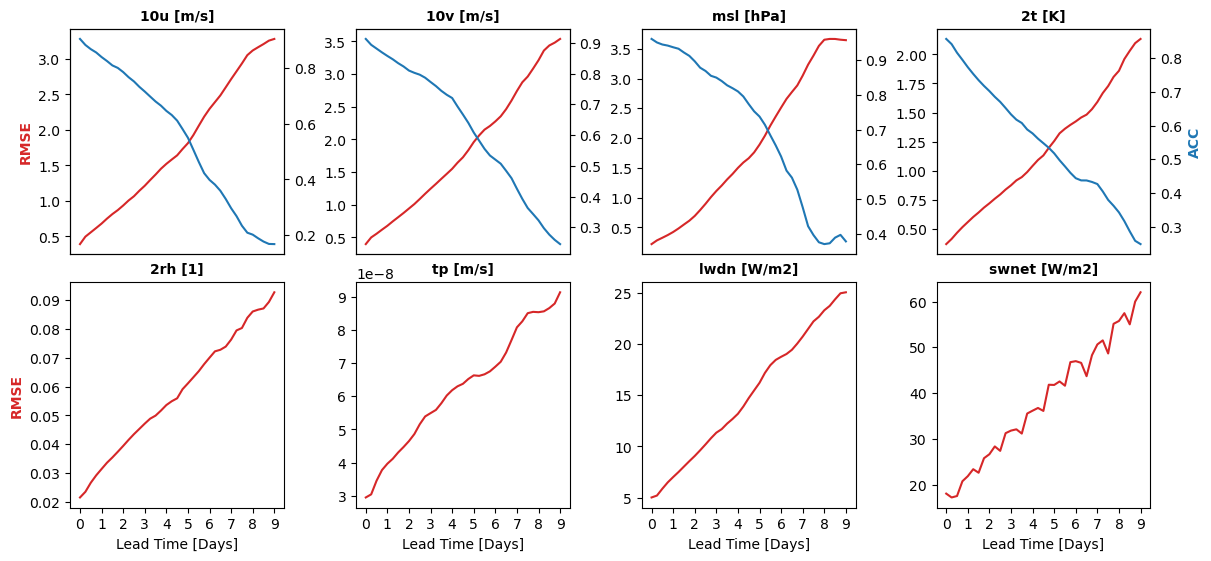

In [18]:
# Create figure
fig, axs = plt.subplots(2, 4, figsize=(12,5.5), layout='constrained')
ax = axs.flat

# Loop over variables
indx = 0
for v, attr in vars.items():
    # Plot RMSE
    x = np.arange(ds_stats.coords['rollout_step'].shape[0])*6
    data1 = ds_stats_subset[f'RMSE_{v}'].isel(time=0).mean(['latitude', 'longitude']).values
    ax[indx].plot(x, data1, color='tab:red', linestyle='-')

    # Plot ACC
    if v in ['10u', '10v', 'msl', '2t']:
        ax2 = ax[indx].twinx()
        data2 = ds_stats_subset[f'ACC_{v}'].isel(time=0).mean(['latitude', 'longitude']).values
        ax2.plot(x, data2, color='tab:blue')

    # Add x label
    if indx > 3:
        ax[indx].set_xticks(x[::4])
        ax[indx].set_xticklabels((x[::4]/24).astype(int))
        ax[indx].set_xlabel('Lead Time [Days]')
    else:
         ax[indx].set_xticks([])

    # Add y label
    if indx in [0, 4]:
        ax[indx].set_ylabel(f'RMSE', color='tab:red', fontweight='bold')
    if indx == 3:
        ax2.set_ylabel(f'ACC', color='tab:blue', fontweight='bold')   
    
    # Set title
    ax[indx].set_title(f'{v} [{attr[1]}]', fontweight='bold', fontsize=10)
    
    indx = indx+1

filename = "plot_rmse.png"
plt.savefig(filename, bbox_inches='tight', pad_inches=0.6, dpi=300)